In [62]:
import argopy
from argopy import DataFetcher as ArgoDataFetcher
import numpy as np
import pandas as pd
from tqdm.auto import tqdm, trange
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import generate_knots, make_lsq_spline
from scipy.ndimage import gaussian_filter1d
from scipy import stats as dists
from scipy.signal import savgol_filter, find_peaks
import ruptures as rpt
from matplotlib import pyplot as plt
import seaborn as sns
from numpy.typing import ArrayLike

In [2]:
box = [
    -75, -45, ## Longitude min/max
    20, 30, ## Latitude min/max
    0, 3000, ## Pressure/depth min/max
    '2011-01', '2011-06', ## Datetime min/max
]
f = ArgoDataFetcher().region(box).load()
data = f.data.to_dataframe()

In [3]:
group_col = 'PLATFORM_CYCLE'
group_fields = ['PLATFORM_NUMBER', 'CYCLE_NUMBER']
cycle_fields = ['LATITUDE', 'LONGITUDE', 'TIME']
reading_fields = ['PRES', 'PRES_ERROR', 'PSAL', 'PSAL_ERROR', 'TEMP', 'TEMP_ERROR']

In [4]:
cycles = data[group_fields + cycle_fields].drop_duplicates().sort_values(group_fields)
cycles.index = (cycles[group_fields[0]].astype(str) + '-' + cycles[group_fields[1]].astype(str)).rename('PLATFORM_CYCLE')

In [5]:
readings = data[group_fields + reading_fields].drop_duplicates().sort_values([*group_fields, 'PRES']).reset_index(drop=True)
readings.insert(0, group_col, readings[group_fields[0]].astype(str) + '-' + readings[group_fields[1]].astype(str))
readings = readings.drop(columns=group_fields)

In [6]:
pres_error = 2.4
temp_error = 0.002
sal_error = 0.01
dbar_to_meter = savgol_filter

In [107]:
def knot_identifier(pres_data: ArrayLike, reading_data: ArrayLike,
                    prominence_mod: float, distance: float,
                    windows: tuple[int, int] = (5, 7)):
    pres_uniform = np.arange(5, pres_data.max(), 5.0)
    reading_uniform = np.interp(pres_uniform, pres_data, reading_data)
    reading_smooth_uniform = savgol_filter(reading_uniform, window_length=windows[0], polyorder=3)
    d2reading_uniform = savgol_filter(reading_smooth_uniform, window_length=windows[1], polyorder=3, deriv=2, delta=5.0)
    curvature = np.abs(d2reading_uniform)
    peak_indicies, props = find_peaks(curvature, prominence=prominence_mod * curvature.std(), distance=distance)
    knot_pres = pres_uniform[peak_indicies]
    return knot_pres, props

In [153]:
prominence = 0.25
distance = 20

results = []
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    temp_knot_pres, temp_props = knot_identifier(cycle_data['PRES'], cycle_data['TEMP'],
                                                 prominence_mod=prominence, distance=distance)
    sal_knot_pres, sal_props = knot_identifier(cycle_data['PRES'], cycle_data['PSAL'],
                                               prominence_mod=prominence, distance=distance)

    temp_t = [*[cycle_data['PRES'].min()] * 4, *temp_knot_pres, *[cycle_data['PRES'].max()] * 4]
    temp_splines = make_lsq_spline(cycle_data['PRES'], cycle_data['TEMP'], temp_t, k=3)
    temp_predict = temp_splines(cycle_data['PRES'])
    temp_rmse = np.sqrt(((cycle_data['TEMP'].values - temp_predict) ** 2).mean())
    delta_temp_predict = temp_splines(cycle_data['PRES'], nu=1)

    sal_t = [*[cycle_data['PRES'].min()] * 4, *sal_knot_pres, *[cycle_data['PRES'].max()] * 4]
    sal_splines = make_lsq_spline(cycle_data['PRES'], cycle_data['PSAL'], sal_t, k=3)
    sal_predict = sal_splines(cycle_data['PRES'])
    sal_rmse = np.sqrt(((cycle_data['PSAL'].values - sal_predict) ** 2).mean())

    results.append({
        'cycle': cycle_number,
        'temp_pres_knots': temp_knot_pres,
        'temp_props': temp_props,
        'temp_splines': temp_splines,
        'temp_rmse': temp_rmse,
        'sal_pres_knots': sal_knot_pres,
        'sal_props': sal_props,
        'sal_splines': sal_splines,
        'sal_rmse': sal_rmse,
    })
results = pd.DataFrame(results)

  0%|          | 0/469 [00:00<?, ?it/s]

In [160]:
delta_temp_predict = temp_splines(cycle_data['PRES'], nu=1)

<Axes: >

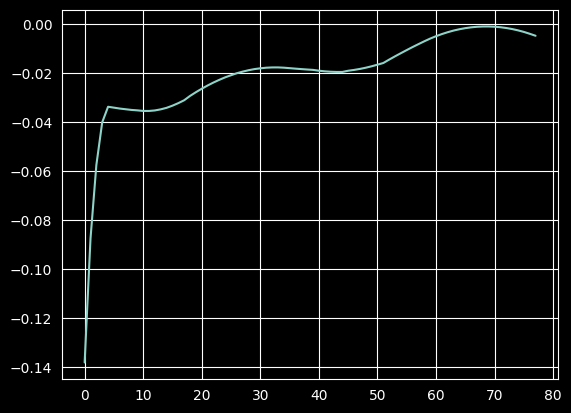

In [161]:
sns.lineplot(delta_temp_predict)

In [156]:
pd.concat([
    results['temp_pres_knots'].apply(lambda x: len(x)),
    results['temp_rmse'],
    results['sal_pres_knots'].apply(lambda x: len(x)),
    results['sal_rmse'],
], axis=1).corr()

,temp_pres_knots,temp_rmse,sal_pres_knots,sal_rmse
temp_pres_knots,1.000000,-0.553664,0.576033,-0.322759
temp_rmse,-0.553664,1.000000,-0.251291,0.464719
sal_pres_knots,0.576033,-0.251291,1.000000,-0.630554
sal_rmse,-0.322759,0.464719,-0.630554,1.000000


<Axes: xlabel='temp_rmse', ylabel='Count'>

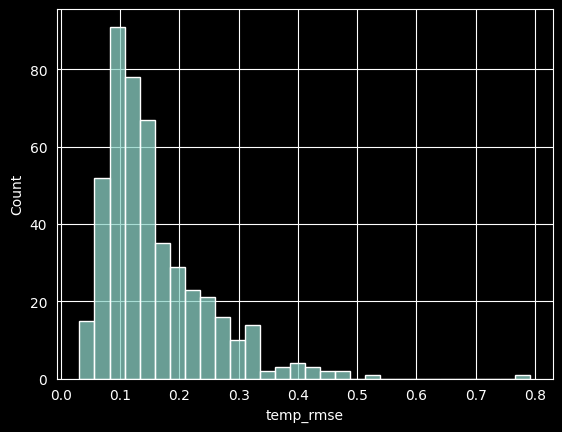

In [157]:
sns.histplot(results['temp_rmse'])

<Axes: xlabel='sal_rmse', ylabel='Count'>

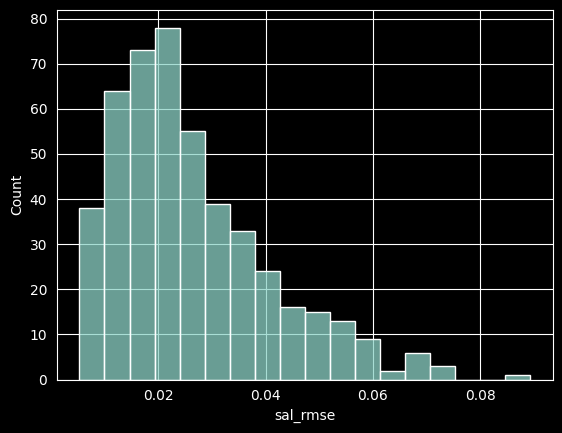

In [158]:
sns.histplot(results['sal_rmse'])